# Fitting SMT Residence Time Data

In [1]:
import multiprocessing as mp
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pytensor
import pymc as pm
import arviz as az
import math
from tqdm import tqdm  # Importing tqdm for progress bar tracking
import seaborn as sns
from statannotations.Annotator import Annotator
import logging
import tempfile
import shutil
import numpyro
import jax
import jaxlib

## SIMULATED DATA TO TEST FITS

### Fitting PDF

In [2]:
# Simulation and model fitting of histogram directly.
# Because we're fittng the histogram (PDF instead of survival function), we'll use (-1)*derivative of the double exponential for fitting.
# I'm including a "plateau" term as well, which represents uniform background noise.
# Mixture of two exponential distributions
def mixture_exponential(t, A, koff_fast, koff_slow, plateau):
    """
    Equation for double exponential + a uniform noise plateau

    Parameters:
    - t, Time array (x values)
    - A, Fraction of fast population
    - koff_fast, koff of fast population
    - koff_slow, koff of slow population
    - plateau, fraction of uniform noise
    """
    exp_fast = koff_fast * np.exp(-koff_fast * t)
    exp_slow = koff_slow * np.exp(-koff_slow * t)
    uniform_noise = plateau / (t.max() - t.min())
    return ((A - plateau) * exp_fast + (1 - A - plateau) * exp_slow + uniform_noise)


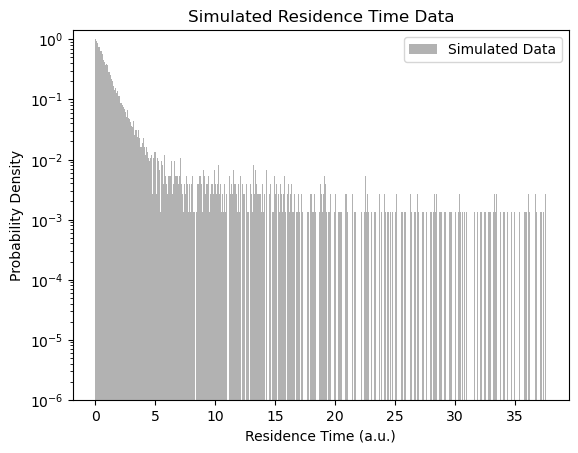

In [3]:
# Simulate synthetic data

# True parameters
A_true = 0.9  # Fraction of the "fast" population
B_true = 0.08  # Fraction of the "slow" population
C_true = 1 - A_true - B_true  # Fraction of the noise
koff_fast_true = 1.2  # Dissociation rate for fast population
koff_slow_true = 0.15  # Dissociation rate for slow population
n_samples = 10000  # Total number of samples

# Generate residence times
fast_population = np.random.exponential(1 / koff_fast_true, int(A_true * n_samples))
slow_population = np.random.exponential(1 / koff_slow_true, int(B_true * n_samples))
noise_population = np.random.uniform(np.concatenate([fast_population, slow_population]).min(), np.concatenate([fast_population, slow_population]).max(), int(C_true * n_samples))

# Combine and scramble data.

# Data with uniform noise
residence_times = np.concatenate([fast_population, slow_population, noise_population])
np.random.shuffle(residence_times)

# Plot histogram of simulated data
plt.hist((residence_times), bins=500, density=True, alpha=0.6, color="gray", label="Simulated Data")
#plt.hist(true_residence_times, bins=50, density=True, alpha=0.6, color="blue", label="De-noised Simulated Data")
plt.xlabel("Residence Time (a.u.)")
plt.ylabel("Probability Density")
plt.yscale("log")
plt.ylim(1e-6)
plt.title("Simulated Residence Time Data")
plt.legend()
plt.show()

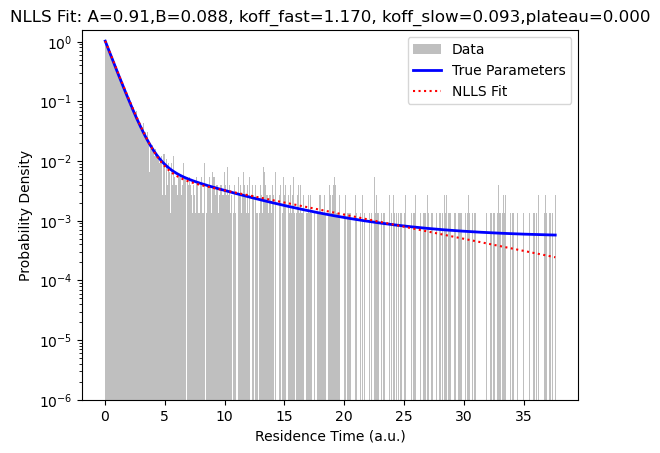

In [4]:
# Histogram data
# Fit for koff_slow is okay in NLLS
bin_num=500
hist, bin_edges = np.histogram(residence_times, bins=bin_num, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Fit the mixture model on the histogram
p0 = [0.8, 0.9, 0.1, 0.01]  # Initial guesses for amp, A, koff_fast, koff_slow, and plateau
popt, pcov = curve_fit(mixture_exponential, bin_centers, hist, p0=p0, bounds=((0,0,0,0),(1,np.inf,np.inf,1)))

A_fit, koff_fast_fit, koff_slow_fit, plateau_fit = popt

# Plot results
plt.hist(residence_times, bins=bin_num, density=True, alpha=0.5, color = "grey", label="Data")

true_value_fitted = mixture_exponential(bin_centers, A_true, koff_fast_true, koff_slow_true, C_true)
plt.plot(bin_centers, true_value_fitted, label="True Parameters", color="blue", linewidth=2, linestyle="solid")

plt.plot(bin_centers, mixture_exponential(bin_centers, *popt), label="NLLS Fit", color="red", linestyle="dotted")
plt.xlabel("Residence Time (a.u.)")
plt.ylabel("Probability Density")
plt.yscale("log")
plt.ylim(1e-6)
plt.legend()
plt.title(f"NLLS Fit: A={A_fit:.2f},B={1-A_fit-plateau_fit:.3f}, koff_fast={koff_fast_fit:.3f}, koff_slow={koff_slow_fit:.3f},plateau={plateau_fit:.3f}")
plt.show()

# Fit is biased towards left of histogram, but it isn't too extreme. NLLS would work fine, I think.


In [5]:
# Define bins
num_bins = 500  # Adjust as needed
bin_edges = np.linspace(residence_times.min(), residence_times.max(), num_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Get bin centers

# Compute histogram
hist_counts, _ = np.histogram(residence_times, bins=bin_edges)

with pm.Model() as model:
    # Priors
    alpha = np.array([1, 1, 1])  # Dirichlet prior for fractions
    weights = pm.Dirichlet("weights", a=alpha)

    # Exponential distributions for fast and slow populations
    koff_slow_lam = pm.Uniform("koff_slow_lam",lower=0,upper=10)
    koff_slow = pm.Exponential("koff_slow", lam=koff_slow_lam)
    koff_alpha = pm.Uniform("koff_alpha",lower=0,upper=10)
    koff_beta = pm.Uniform("koff_beta",lower=0,upper=10)

    koff_fast = pm.Gamma("koff_fast",alpha=koff_alpha,beta=koff_beta)    
    pm.Potential("valid_koff", pm.math.switch(koff_fast > koff_slow, 0, -np.inf))
        
    # Constrained Uniform noise term: uniform noise between the minimum and maximum residence time
    noise_min = np.min(bin_centers)
    noise_max = np.max(bin_centers)
    noise_range = noise_max - noise_min  # Calculate the range of residence times
    
    # Noise fraction should be a fraction of the total population
    uniform_noise = 1/(noise_max - noise_min)
      
    # Expected probability density for each bin center
    expected_density = (
        weights[0] * koff_fast * pm.math.exp(-koff_fast * bin_centers) +
        weights[1] * koff_slow * pm.math.exp(-koff_slow * bin_centers) +
        weights[2] * uniform_noise  # Scaling noise fraction with the noise term
    )

    # Normalize to expected counts (scale by bin width and sample size)
    bin_width = np.diff(bin_edges)
    expected_counts = expected_density * bin_width * len(residence_times)

    # Likelihood: Observed histogram follows a Poisson distribution
    y_obs = pm.Poisson("y_obs", mu=expected_counts, observed=hist_counts)

    # MCMC Sampling
    trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, nuts_sampler="nutpie")


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.35,7
,2000,0,0.35,15
,2000,0,0.33,7
,2000,0,0.35,7


In [6]:
# Summary statistics
summary = az.summary(
    trace, var_names=["weights", "koff_fast", "koff_slow"], round_to=4
)
print(summary)

              mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
weights[0]  0.9062  0.0057  0.8954   0.9164     0.0001   0.0001  1707.7569   
weights[1]  0.0766  0.0055  0.0663   0.0868     0.0001   0.0001  2425.6359   
weights[2]  0.0171  0.0047  0.0078   0.0253     0.0002   0.0001   837.7660   
koff_fast   1.1760  0.0167  1.1471   1.2093     0.0004   0.0002  2257.5548   
koff_slow   0.1267  0.0178  0.0912   0.1575     0.0006   0.0004   873.6835   

             ess_tail   r_hat  
weights[0]  2914.5736  1.0015  
weights[1]  2411.0855  1.0006  
weights[2]   541.3964  1.0035  
koff_fast   2845.6520  1.0005  
koff_slow    607.7818  1.0036  


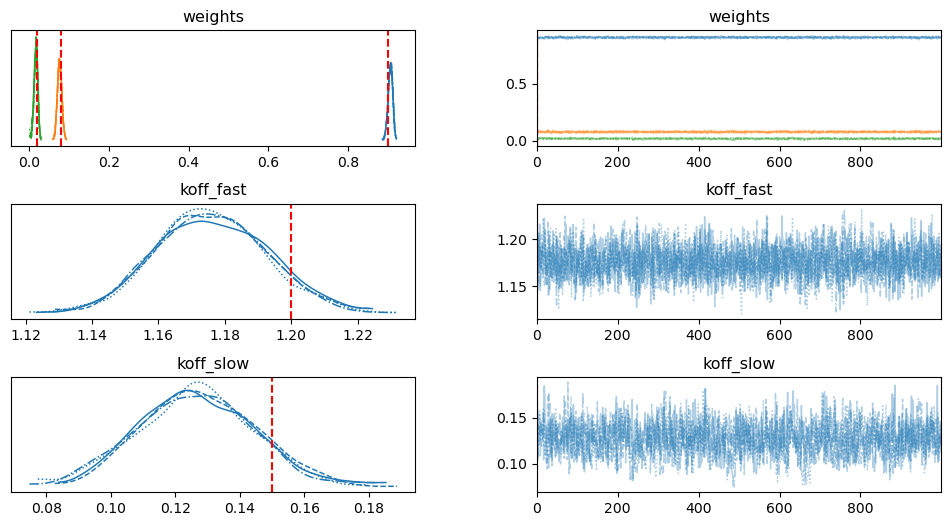

In [7]:
true_values = {
    "koff_fast": [koff_fast_true],
    "koff_slow": [koff_slow_true],
    "weights": [A_true, B_true, C_true]
}
az.plot_trace(trace, var_names=["weights", "koff_fast", "koff_slow"])
# Add vertical lines for true values
for param, true_value in true_values.items():
    plt.gcf()  
    axes = plt.gcf().axes  
    for ax in axes:
        if param in ax.get_title():
            for value in true_value:
                ax.axvline(value, color="red", linestyle="--", label="True Value")

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

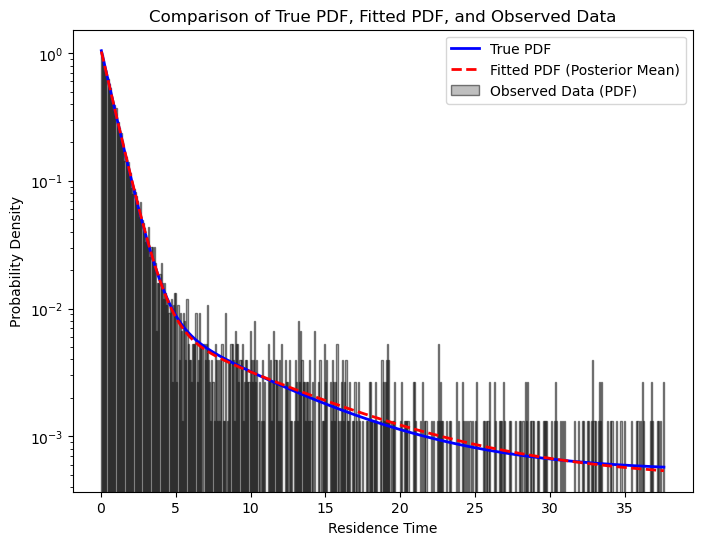

In [8]:
# Extract posterior means from the PyMC trace
weights_post = trace.posterior["weights"].mean(dim=("chain", "draw")).values
koff_slow_post = trace.posterior["koff_slow"].mean(dim=("chain", "draw")).values
koff_fast_post = trace.posterior["koff_fast"].mean(dim=("chain", "draw")).values
#noise_fraction_post = trace.posterior["noise_fraction"].mean(dim=("chain", "draw")).values


# Compute the fitted probability density function
fitted_pdf = (
    weights_post[0] * koff_fast_post * np.exp(-koff_fast_post * bin_centers) +
    weights_post[1] * koff_slow_post * np.exp(-koff_slow_post * bin_centers) +
    weights_post[2]/(residence_times.max() - residence_times.min())  # Normalized uniform noise
)

# Normalize histogram to probability density
hist_pdf, bin_edges = np.histogram(residence_times, bins=bin_edges, density=True)

# Compute the true PDF using true parameters
true_pdf = (
    A_true * koff_fast_true * np.exp(-koff_fast_true * bin_centers) +
    B_true * koff_slow_true * np.exp(-koff_slow_true * bin_centers) +
    C_true / (np.max(residence_times) - np.min(residence_times))  # True uniform noise contribution
)

# Plot results
plt.figure(figsize=(8, 6))

# Plot histogram as a PDF
plt.bar(bin_centers, hist_pdf, width=np.diff(bin_edges)[0], alpha=0.5, label="Observed Data (PDF)", color="gray", edgecolor="black")

# Plot true PDF
plt.plot(bin_centers, true_pdf, label="True PDF", color="blue", linestyle="solid", linewidth=2)

# Plot fitted PDF
plt.plot(bin_centers, fitted_pdf, label="Fitted PDF (Posterior Mean)", color="red", linestyle="dashed", linewidth=2)

plt.xlabel("Residence Time")
plt.ylabel("Probability Density")
plt.yscale("log")
plt.legend()
plt.title("Comparison of True PDF, Fitted PDF, and Observed Data")
plt.show()


### Survival Curve Approach


In [9]:
def calculate_survival_probability(track_lengths, frame_interval=0.25, max_frames=500):
    """
    Calculate the survival probability using Cyna's method. Is this more or less what you're doing?

    Parameters:
    - track_lengths: an array of track lengths
    - frame_interval: Time per frame in seconds (default 0.25s).
    - max_frames: Maximum allowed frames for the movie (default 500 frames).

    Returns:
    - survival_df: DataFrame with time and survival probability.
    """
    bins = np.arange(1, max_frames)  # 1-frame increments from 1 to 499
    histogram_counts, bin_edges = np.histogram(track_lengths, bins=bins)
    cdf = np.cumsum(histogram_counts) / np.sum(histogram_counts)
    survival_probability = 1 - cdf

    # Exclude the last "filled" CDF bin to sync up bin length with time values
    survival_probability = survival_probability[:-1]

    # Time points are the floor of the time values per 1-CDF bin
    # Exclude the first and last bin edges, scale by frame interval
    time_values = (bin_edges[1:-1]) * frame_interval

    # Create a DataFrame for survival probability
    survival_df = pd.DataFrame({
        'time': time_values,
        'survival_probability': survival_probability
    })

    return survival_df

def plot_survival_curve(survival_df):
    """
    Plot the survival curve.

    Parameters:
    - survival_df: DataFrame containing time and survival probability.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(
        survival_df['time'], 
        survival_df['survival_probability'], 
        label="Survival Curve",
        color="blue"
    )
    plt.xlabel("Time (a.u.)")
    plt.ylabel("Survival Probability")
    plt.title("Track Survival Curve")
    plt.legend()

def plot_fitted_survival(t, koff_fast, koff_slow, A, B, C, linestyle="dotted",color="red"):
    y_vals = (A) * np.exp(-koff_fast * t) + (B) * np.exp(-koff_slow * t) + (C/(t.max()-t.min()))
    plt.plot(t, y_vals, linestyle=linestyle, color=color)
    plt.yscale('log')

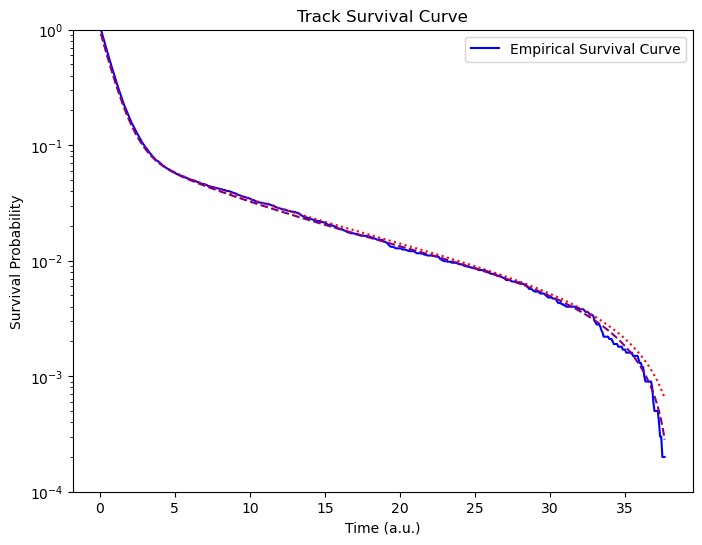

In [10]:
# Compute histogram
hist, bin_edges = np.histogram(residence_times, bins=500, density=True)

# Compute the empirical survival function (reversed cumulative sum)
survival_prob = np.cumsum(hist[::-1])[::-1]  # Reverse cumulative sum
survival_prob = survival_prob / survival_prob[0]  # Normalize

# Create survival dataframe
survival_df = pd.DataFrame({
    'time': bin_edges[1:],  
    'survival_probability': survival_prob
})

# Plot empirical survival curve
plt.figure(figsize=(8, 6))
plt.plot(
    survival_df['time'], 
    survival_df['survival_probability'], 
    label="Empirical Survival Curve",
    color="blue"
)
plt.xlabel("Time (a.u.)")
plt.ylabel("Survival Probability")
plt.title("Track Survival Curve")
plt.yscale('log')
plt.ylim(1e-4,1)
plt.grid(False)

# Function to plot fitted survival curve
def plot_fitted_survival(t, koff_fast, koff_slow, A, B, C, linestyle="dotted", color="red"):
    y_vals = A * np.exp(-koff_fast * t) + B * np.exp(-koff_slow * t) + C * (residence_times.max() - t) / (residence_times.max() - residence_times.min())
    plt.plot(t, y_vals, linestyle=linestyle, color=color)

# Plot Bayesian model fit
plot_fitted_survival(
    survival_df['time'], 
    summary['mean']['koff_fast'], summary['mean']['koff_slow'], 
    summary['mean']['weights[0]'], summary['mean']['weights[1]'], summary['mean']['weights[2]']
)

# Plot ground truth survival function
plot_fitted_survival(
    survival_df['time'], 
    koff_fast_true, koff_slow_true, 
    A_true, B_true, C_true, 
    linestyle="dashed", color="purple"
)
plt.legend()
plt.show()


## REAL DATA

In [11]:
# Read data in chunks for my potato computer
file_path = '/path/to/df_tracks.csv'
chunksize = 10000
chunk_list = []
for chunk in pd.read_csv(file_path, chunksize=chunksize):
    chunk_list.append(chunk)

df = pd.concat(chunk_list, ignore_index=True)
df['track_length'] = df['track_length'] * 0.25


In [18]:
# Just grabbing a couple random ones to try this out on
fov_id_str = '1854872-U2OS-0002_WellE02_Point00'
filtered_data_H2B = df[df['fov_id_str'] == fov_id_str]

fov_id_str = '1854872-U2OS-0007_WellI05_Point01'
filtered_data = df[df['fov_id_str'] == fov_id_str]

In [19]:
# Define bins
residence_times = filtered_data['track_length']

num_bins = 500  # Adjust as needed

bin_edges = np.linspace(0, residence_times.max(), num_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Get bin centers

# Compute histogram
hist_counts, _ = np.histogram(residence_times, bins=bin_edges)

with pm.Model() as model:
    # Priors
    alpha = np.array([1, 1, 1])  # Dirichlet prior for fractions
    weights = pm.Dirichlet("weights", a=alpha)

    # Exponential distributions for fast and slow populations
    # Either Uniform or HalfNormal priors will work (HalfNormal example used above)
    koff_slow_lam = pm.Uniform("koff_slow_lam",lower=0,upper=10)
    koff_slow = pm.Exponential("koff_slow", lam=koff_slow_lam)
    koff_alpha = pm.Uniform("koff_alpha",lower=0,upper=10)
    koff_beta = pm.Uniform("koff_beta",lower=0,upper=10)

    koff_fast = pm.Gamma("koff_fast",alpha=koff_alpha,beta=koff_beta)
    pm.Potential("valid_koff", pm.math.switch(koff_fast > koff_slow, 0, -np.inf))
    
    # Constrained Uniform noise term: uniform noise between the minimum and maximum residence time
    noise_min = np.min(bin_centers)
    noise_max = np.max(bin_centers)
    noise_range = noise_max - noise_min  # Calculate the range of residence times
    uniform_noise = 1/(noise_max - noise_min)   
        
    # Expected probability density for each bin center
    expected_density = (
        weights[0] * koff_fast * pm.math.exp(-koff_fast * bin_centers) +
        weights[1] * koff_slow * pm.math.exp(-koff_slow * bin_centers) +
        weights[2] * uniform_noise  # Scaling noise fraction with the noise term
    )

    # Normalize to expected counts (scale by bin width and sample size)
    bin_width = np.diff(bin_edges)
    expected_counts = expected_density * bin_width * len(residence_times)

    # Likelihood: Observed histogram follows a Poisson distribution
    y_obs = pm.Poisson("y_obs", mu=expected_counts, observed=hist_counts)

    # MCMC Sampling
    trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, nuts_sampler="nutpie")


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.25,15
,2000,0,0.27,19
,2000,0,0.28,31
,2000,0,0.28,15


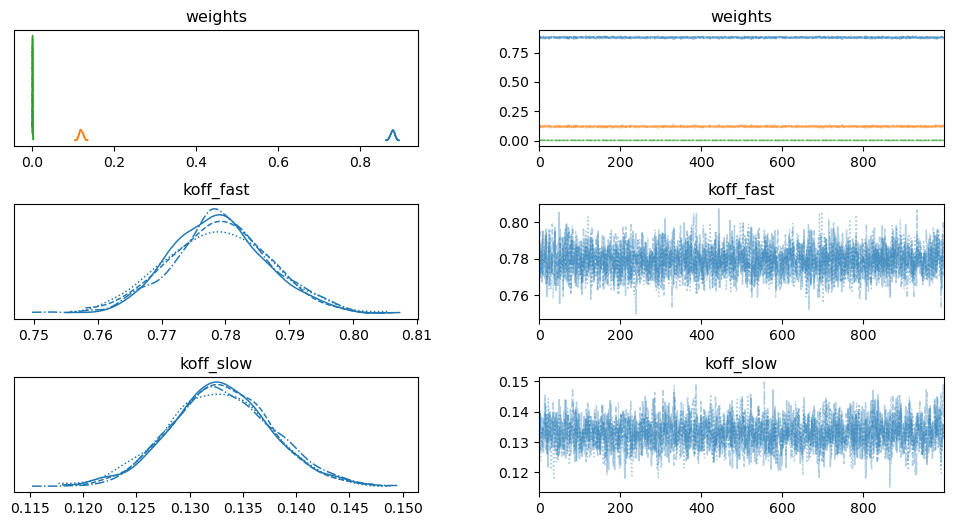

              mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
weights[0]  0.8789  0.0051  0.8698   0.8887     0.0001   0.0001  2728.7473   
weights[1]  0.1198  0.0049  0.1106   0.1288     0.0001   0.0001  3088.9169   
weights[2]  0.0013  0.0005  0.0004   0.0024     0.0000   0.0000   846.4831   
koff_fast   0.7791  0.0079  0.7645   0.7944     0.0001   0.0001  3346.4013   
koff_slow   0.1329  0.0048  0.1240   0.1422     0.0001   0.0001  1850.3758   

             ess_tail   r_hat  
weights[0]  2788.9073  1.0009  
weights[1]  3076.5008  1.0007  
weights[2]   868.5573  1.0015  
koff_fast   3220.0157  1.0018  
koff_slow   2031.4001  1.0012  


In [20]:
az.plot_trace(trace, var_names=["weights", "koff_fast", "koff_slow"])
plt.subplots_adjust(hspace=0.5, wspace=0.3)  # Increase vertical and horizontal spacing
plt.show()

# Summary statistics
summary = az.summary(
    trace, var_names=["weights", "koff_fast", "koff_slow"], round_to=4
)
print(summary)

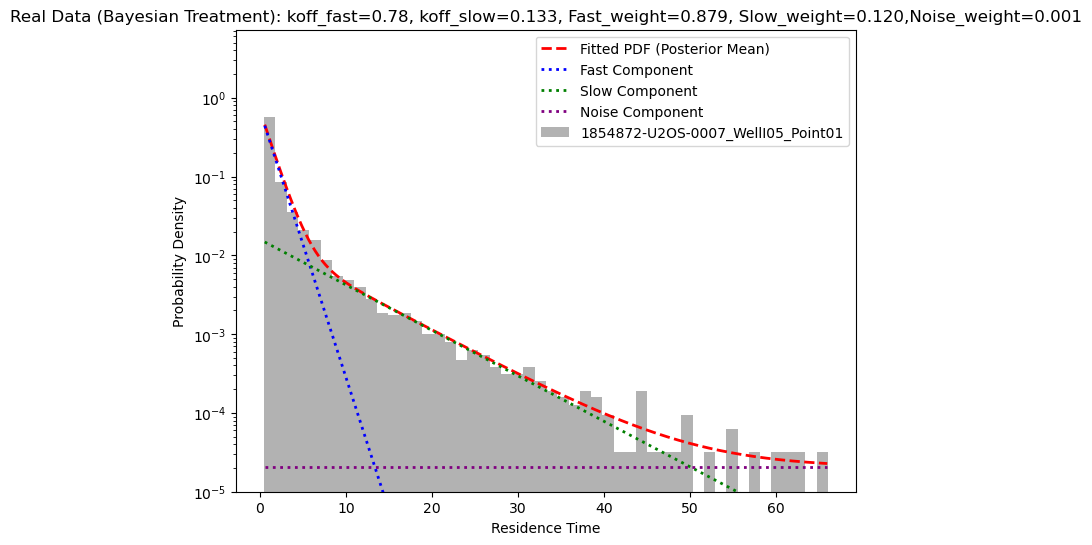

In [22]:
# Extract posterior means from the PyMC trace
weights_post = trace.posterior["weights"].mean(dim=("chain", "draw")).values
koff_slow_post = trace.posterior["koff_slow"].mean(dim=("chain", "draw")).values
koff_fast_post = trace.posterior["koff_fast"].mean(dim=("chain", "draw")).values
#noise_fraction_post = trace.posterior["noise_fraction"].mean(dim=("chain", "draw")).values

num_bins = 500  # Adjust as needed
bin_edges = np.linspace(residence_times.min(), residence_times.max(), num_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Get bin centers

# Compute the fitted probability density function
fitted_pdf = (
    weights_post[0] * koff_fast_post * np.exp(-koff_fast_post * bin_centers) +
    weights_post[1] * koff_slow_post * np.exp(-koff_slow_post * bin_centers) +
    (weights_post[2])/(residence_times.max() - 1)  # Normalized uniform noise
)

# Compute each component's probability density
fast_pdf = weights_post[0] * koff_fast_post * np.exp(-koff_fast_post * bin_centers)
slow_pdf = weights_post[1] * koff_slow_post * np.exp(-koff_slow_post * bin_centers)
noise_pdf = [(weights_post[2]) / (residence_times.max() - 1)] * len(bin_centers)



# Compute histogram
hist_counts, _ = np.histogram(residence_times, bins=bin_edges)


# Normalize histogram to probability density
hist_pdf, bin_edges = np.histogram(residence_times, bins=bin_edges, density=True)

# Plot results
plt.figure(figsize=(8, 6))

# Plot histogram as a PDF
plt.plot(bin_centers, fitted_pdf, label="Fitted PDF (Posterior Mean)", color="red", linestyle="dashed", linewidth=2)
# Plot individual components
plt.plot(bin_centers, fast_pdf, label="Fast Component", color="blue", linewidth=2, linestyle="dotted")
plt.plot(bin_centers, slow_pdf, label="Slow Component", color="green", linewidth=2, linestyle="dotted")
plt.plot(bin_centers, noise_pdf, label="Noise Component", color="purple", linewidth=2, linestyle="dotted")


# Plot histogram of simulated data
plt.hist(filtered_data['track_length'], bins=50, density=True, alpha=0.6, color="gray", label=fov_id_str)


# Add labels and legend
plt.xlabel("Residence Time")
plt.ylabel("Probability Density")
plt.yscale("log")
plt.ylim(1e-5)
plt.legend()
plt.title("Comparison of True PDF, Fitted PDF, and Observed Data")

plt.title(f"Real Data (Bayesian Treatment): koff_fast={koff_fast_post:.2f}, koff_slow={koff_slow_post:.3f}, Fast_weight={weights_post[0]:.3f}, Slow_weight={weights_post[1]:.3f},Noise_weight={weights_post[2]:.3f}")
plt.legend()
plt.show()

# Much better fit when compared with the NLLS approach

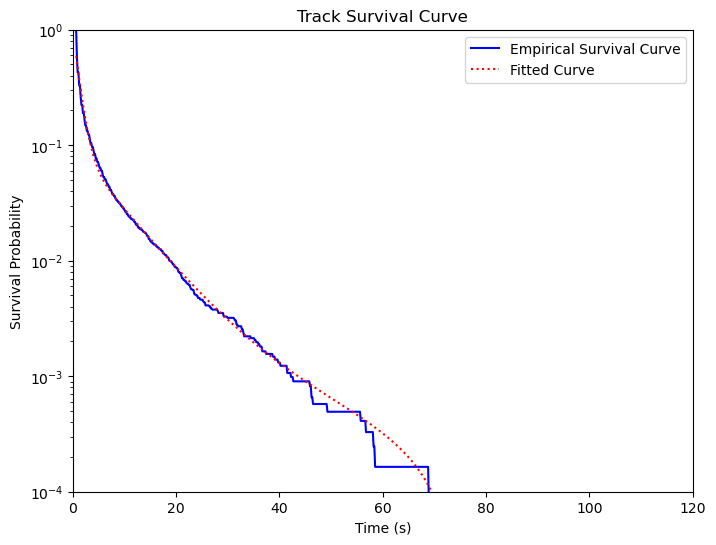

In [20]:
# Compute histogram
hist, bin_edges = np.histogram(residence_times, bins=bin_edges, density=True)

# Compute the empirical survival function (reversed cumulative sum)
survival_prob = np.cumsum(hist[::-1])[::-1]  # Reverse cumulative sum
survival_prob = survival_prob / survival_prob[0]  # Normalize

# Create survival dataframe
survival_df = pd.DataFrame({
    'time': bin_edges[1:],  
    'survival_probability': survival_prob
})

# Plot empirical survival curve
plt.figure(figsize=(8, 6))
plt.plot(
    survival_df['time'], 
    survival_df['survival_probability'], 
    label="Empirical Survival Curve",
    color="blue"
)
plt.xlabel("Time (s)")
plt.ylabel("Survival Probability")
plt.title("Track Survival Curve")
plt.xlim(0,120)
plt.yscale('log')
plt.ylim(1e-4,1)
plt.grid(False)

# Function to plot fitted survival curve
def plot_fitted_survival(t, koff_fast, koff_slow, A, B, C, linestyle="dotted", color="red"):
    y_vals = A * np.exp(-koff_fast * t) + B * np.exp(-koff_slow * t) + C * (t.max() - t) / (t.max() - 1)
    plt.plot(t, y_vals, linestyle=linestyle, color=color,label="Fitted Curve")

# Plot Bayesian model fit
plot_fitted_survival(
    survival_df['time'], 
    summary['mean']['koff_fast'], summary['mean']['koff_slow'], 
    summary['mean']['weights[0]'], summary['mean']['weights[1]'], summary['mean']['weights[2]']
)
plt.legend()
plt.show()


In [1]:
### Overlaying all tracks onto one

In [34]:
def fit_fov(residence_times, num_bins=500):
    bin_edges = np.linspace(0, residence_times.max(), num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    hist_counts, _ = np.histogram(residence_times, bins=bin_edges)

    with pm.Model() as model:
        # Mixture weights
        weights = pm.Dirichlet("weights", a=np.array([10, 5, 1]))
        
        # Fast and slow components
        koff_slow_lam = pm.Uniform("koff_slow_lam", lower=0,upper=10)
        koff_slow = pm.Exponential("koff_slow", lam=koff_slow_lam)
        koff_alpha = pm.Uniform("koff_alpha", lower=0,upper=10)
        koff_beta = pm.Uniform("koff_beta", lower=0,upper=10)
        koff_fast = pm.Gamma("koff_fast", alpha=koff_alpha, beta=koff_beta)
        pm.Potential("valid_koff", pm.math.switch(koff_fast > koff_slow, 0, -np.inf))

        # Uniform noise
        noise_min, noise_max = np.min(bin_centers), np.max(bin_centers)
        uniform_noise = 1/(residence_times.max() - residence_times.min())

        # Expected densities
        expected_density = (
            weights[0] * koff_fast * pm.math.exp(-koff_fast * bin_centers) +
            weights[1] * koff_slow * pm.math.exp(-koff_slow * bin_centers) +
            weights[2] * uniform_noise
        )

        expected_counts = expected_density * np.diff(bin_edges) * len(residence_times)
        y_obs = pm.Poisson("y_obs", mu=expected_counts, observed=hist_counts)
        
        trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.95,
                          nuts_sampler="nutpie", progressbar=False)
    
    summary = az.summary(trace)
    return trace

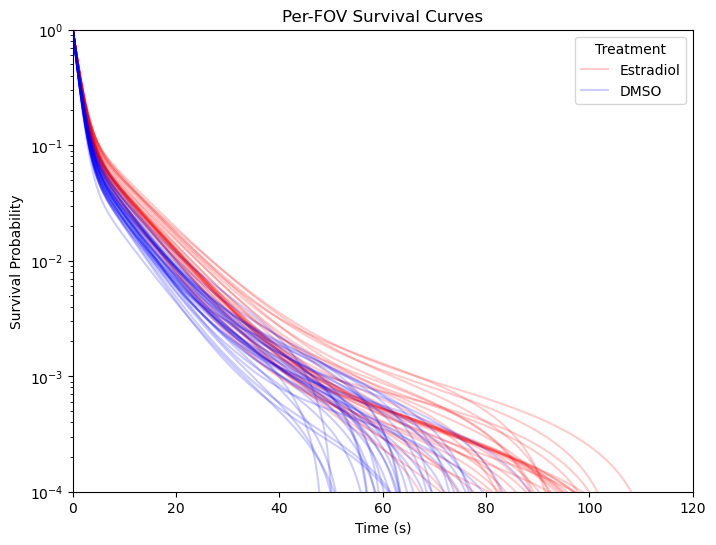

In [35]:
groups = [
    ("DNA-binding mutant (R234A)", "Estradiol", "red"),
    ("DNA-binding mutant (R234A)", "DMSO", "blue")
]

# DNA-binding mutant (R234A)
# RNA-binding mutant #2 (R)
# RNA-binding mutant #3 (RRGG, RG)
# WT ERa pool
# RNA-binding mutant #1 (RRGG)

plt.figure(figsize=(8, 6))

# --- Fit and plot each group ---
for cell_line, molecule, color in groups:
    group_df = df[
        (df['Cell Line ID'] == cell_line) &
        (df['Molecule Name'] == molecule)
    ]

    fov_ids = group_df['fov_id_str'].unique()

    for i, fov_id in enumerate(fov_ids):
        filtered_data = group_df[group_df['fov_id_str'] == fov_id]
        residence_times = filtered_data['track_length'].values

        trace = fit_fov(residence_times)

        # Extract posterior means
        weights = trace.posterior["weights"].mean(dim=("chain", "draw")).values
        koff_fast = trace.posterior["koff_fast"].mean(dim=("chain", "draw")).values
        koff_slow = trace.posterior["koff_slow"].mean(dim=("chain", "draw")).values

        # Compute survival curve
        t = np.linspace(0, residence_times.max(), 200)
        y_fit = (
            weights[0] * np.exp(-koff_fast * t) +
            weights[1] * np.exp(-koff_slow * t) +
            weights[2] * (t.max() - t) / (t.max() - 1)
        )

        plt.plot(
            t, y_fit,
            alpha=0.2,
            color=color,
            label=f"{molecule}" if i == 0 else None
        )

# --- Formatting ---
plt.xlim(0, 120)
plt.yscale('log')
plt.ylim(1e-4, 1)
plt.xlabel("Time (s)")
plt.ylabel("Survival Probability")
plt.title("Per-FOV Survival Curves")
plt.legend(title="Treatment")
plt.show()


Representative FOV: 1854872-U2OS-0002_WellF10_Point01


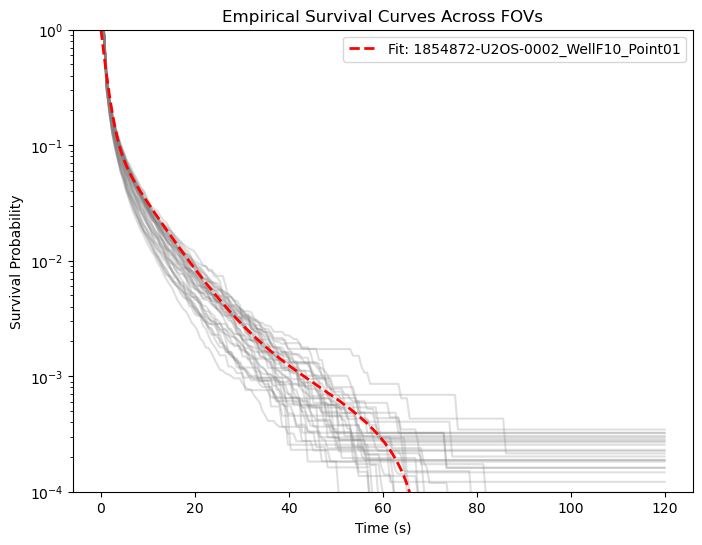

In [137]:
# DNA-binding mutant (R234A)
# RNA-binding mutant #2 (R)
# RNA-binding mutant #3 (RRGG, RG)
# WT ERa pool
# RNA-binding mutant #1 (RRGG)

group_df = df[
    (df['Cell Line ID'] == 'RNA-binding mutant #3 (RRGG, RG)') &
    (df['Molecule Name'] == 'DMSO')
]

fov_ids = group_df['fov_id_str'].unique()
rep_fov_id = np.random.choice(fov_ids)
#rep_fov_id = '1854872-U2OS-0005_WellG13_Point03'
print(f"Representative FOV: {rep_fov_id}")

rep_data = group_df[group_df['fov_id_str'] == rep_fov_id]['track_length'].values

t_grid = np.linspace(0, 120, 200)
plt.figure(figsize=(8,6))

for fov_id in fov_ids:
    fov_data = group_df[group_df['fov_id_str'] == fov_id]['track_length'].values
    
    hist, bin_edges = np.histogram(fov_data, bins=500, density=True)
    survival_prob = np.cumsum(hist[::-1])[::-1]
    survival_prob /= survival_prob[0]
    
    survival_interp = np.interp(t_grid, bin_edges[1:], survival_prob)
    plt.plot(t_grid, survival_interp, alpha=0.25, color='gray')

plt.xlabel("Time (s)")
plt.ylabel("Survival Probability")
plt.yscale('log')
plt.ylim(1e-4,1)
plt.title("Empirical Survival Curves Across FOVs")

num_bins = 500
bin_edges = np.linspace(0, rep_data.max(), num_bins+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
hist_counts, _ = np.histogram(rep_data, bins=bin_edges)

with pm.Model() as model:
    weights = pm.Dirichlet("weights", a=np.array([10,5,1]))
    koff_slow_lam = pm.Uniform("koff_slow_lam", lower=0,upper=10)
    koff_slow = pm.Exponential("koff_slow", lam=koff_slow_lam)
    koff_alpha = pm.Uniform("koff_alpha", lower=0,upper=10)
    koff_beta = pm.Uniform("koff_beta", lower=0,upper=10)
    koff_fast = pm.Gamma("koff_fast", alpha=koff_alpha, beta=koff_beta)
    pm.Potential("valid_koff", pm.math.switch(koff_fast > koff_slow, 0, -np.inf))
    
    uniform_noise = 1/(rep_data.max() - 1)
    expected_density = (
        weights[0]*koff_fast*pm.math.exp(-koff_fast*bin_centers) +
        weights[1]*koff_slow*pm.math.exp(-koff_slow*bin_centers) +
        (weights[2]*uniform_noise)
    )
    expected_counts = expected_density * np.diff(bin_edges) * len(rep_data)
    
    y_obs = pm.Poisson("y_obs", mu=expected_counts, observed=hist_counts)
    trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, nuts_sampler="nutpie", progressbar=False)

weights_post = trace.posterior["weights"].mean(dim=("chain","draw")).values
koff_fast_post = trace.posterior["koff_fast"].mean(dim=("chain","draw")).values
koff_slow_post = trace.posterior["koff_slow"].mean(dim=("chain","draw")).values

fitted_survival = (
    weights_post[0]*np.exp(-koff_fast_post*t_grid) +
    weights_post[1]*np.exp(-koff_slow_post*t_grid) +
    weights_post[2]*(rep_data.max()-t_grid)/(rep_data.max()-1)
)

plt.plot(t_grid, fitted_survival, color='red', linewidth=2, linestyle='--', label=f'Fit: {rep_fov_id}')
plt.legend()
plt.show()


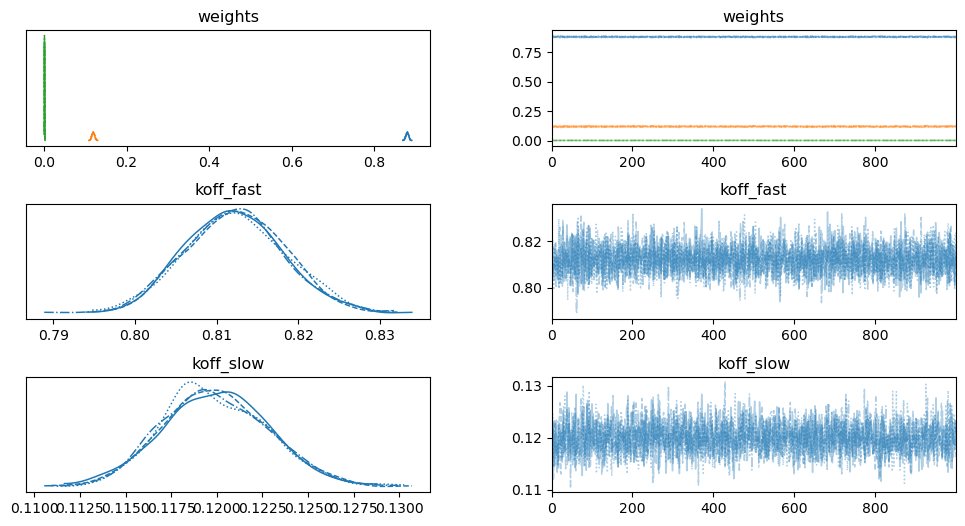

              mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
weights[0]  0.8799  0.0034  0.8738   0.8864     0.0001   0.0000  3115.4413   
weights[1]  0.1191  0.0033  0.1125   0.1250     0.0001   0.0000  3532.6615   
weights[2]  0.0010  0.0003  0.0005   0.0015     0.0000   0.0000   861.0760   
koff_fast   0.8123  0.0061  0.8014   0.8241     0.0001   0.0001  4110.5804   
koff_slow   0.1200  0.0029  0.1145   0.1254     0.0001   0.0000  2377.3589   

             ess_tail   r_hat  
weights[0]  3129.0883  1.0004  
weights[1]  3005.4409  1.0006  
weights[2]  1028.2508  1.0019  
koff_fast   2820.4822  1.0007  
koff_slow   3050.6687  1.0013  


In [118]:
az.plot_trace(trace, var_names=["weights", "koff_fast", "koff_slow"])
plt.subplots_adjust(hspace=0.5, wspace=0.3)  # Increase vertical and horizontal spacing
plt.show()

# Summary statistics
summary = az.summary(
    trace, var_names=["weights", "koff_fast", "koff_slow"], round_to=4
)
print(summary)

## Attempting Bayesian fits on whole dataset

In [ ]:
def fit_model(fov_id, df):
    # Subset the data for the current fov_id_str
    subset_data = df[df["fov_id_str"] == fov_id]

    # Define bins
    residence_times = subset_data['track_length']
    
    num_bins = 500  # Adjust as needed
    bin_edges = np.linspace(1, 120, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Get bin centers
    
    # Compute histogram
    hist_counts, _ = np.histogram(residence_times, bins=bin_edges)

    with pm.Model() as model:
        # Priors
        alpha = np.array([1, 1, 1])  # Dirichlet prior for fractions
        weights = pm.Dirichlet("weights", a=alpha)
    
        # Exponential distributions for fast and slow populations
        koff_slow_lam = pm.Uniform("koff_slow_lam",lower=0,upper=10)
        koff_slow = pm.Exponential("koff_slow", lam=koff_slow_lam)
        koff_alpha = pm.Uniform("koff_alpha",lower=0,upper=10)
        koff_beta = pm.Uniform("koff_beta",lower=0,upper=10)
    
        koff_fast = pm.Gamma("koff_fast",alpha=koff_alpha,beta=koff_beta)
        pm.Potential("valid_koff", pm.math.switch(koff_fast > koff_slow, 0, -np.inf))
        
        # Constrained Uniform noise term: uniform noise between the minimum and maximum residence time
        noise_min = np.min(bin_centers)
        noise_max = np.max(bin_centers)
        noise_range = noise_max - noise_min  # Calculate the range of residence times
        uniform_noise = 1/(noise_max - noise_min)   
            
        # Expected probability density for each bin center
        expected_density = (
            weights[0] * koff_fast * pm.math.exp(-koff_fast * bin_centers) +
            weights[1] * koff_slow * pm.math.exp(-koff_slow * bin_centers) +
            weights[2] * uniform_noise  # Scaling noise fraction with the noise term
        )
    
        # Normalize to expected counts (scale by bin width and sample size)
        bin_width = np.diff(bin_edges)
        expected_counts = expected_density * bin_width * len(residence_times)
    
        # Likelihood: Observed histogram follows a Poisson distribution
        y_obs = pm.Poisson("y_obs", mu=expected_counts, observed=hist_counts)
    
        # MCMC Sampling
        trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, nuts_sampler="nutpie")

    summary = az.summary(trace, var_names=["weights", "koff_slow", "koff_fast"], hdi_prob=0.94)
    summary["fov_id_str"] = fov_id
    return summary


In [ ]:
# Small test
#fov_id_str = ['1854872-U2OS-0005_WellE05_Point03','1854872-U2OS-0007_WellF04_Point00']

# Full scale
# Unique fov_id_str values
unique_fov_ids = df["fov_id_str"].unique()

# Container to store results
results = []

logger = logging.getLogger("pymc")
logger.setLevel(logging.WARNING)

def run_fit(fov_id):
    """Wrapper function for parallel execution"""
    return fit_model(fov_id, df)

# Write results to avoid recomputing
#summary_df.to_csv("model_fits_summary_hist.csv", index=False)


In [ ]:
start_time = time.time()  # Start timing
for i, fov_id in enumerate(unique_fov_ids, start=1):
    summary = fit_model(fov_id, df)
    results.append(summary)

end_time = time.time()  # End timing
elapsed_time = end_time - start_time  # Compute elapsed time

print(f"Total job time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")


In [ ]:
combined_df = pd.concat(results, ignore_index=False)
combined_df['mean'].max()

## Analysis

### Preprocessing

In [ ]:
# Read processed file in
#combined_df = pd.concat(res, ignore_index=False)
print(combined_df)
#file_path = '/path/to/model_fits_summary.csv'

# Forgot to save parameter labels... oops! The order is weights[0], weights[1], weights[2], koff_slow, koff_fast
#summary_df = pd.read_csv(file_path)
#summary_df

In [ ]:
# Extract the unique metadata for each fov_id_str from df
metadata = df[['fov_id_str', 'Cell Line ID', 'Molecule Name', 'Molecule Concentration','plate_barcode']].drop_duplicates()

# Add the metadata columns to summary_df
summary_df = combined_df.merge(metadata, on='fov_id_str', how='left').set_axis(combined_df.index)
summary_df

In [ ]:
# Adding in parameter labels FIXME: this step should be baked into initial save. Save the summary df object with these labels instead then delete this step
#parameter_labels = ['weights[0]', 'weights[1]', 'weights[2]', 'koff_slow', 'koff_fast']

# Number of rows per fov_id_str
#num_parameters = len(parameter_labels)
#unique_fovs = summary_df['fov_id_str'].unique()  # Assuming the index represents fov_id_str

# Assign parameter labels
summary_df['parameter'] = summary_df.index
summary_df

summary_df.to_csv("/path/to/model_fits_summary_full.csv", index=False)



### Boxplot

In [ ]:
def plot_parameter_boxplot(summary_df, molecule_name, molecule_concentration, parameter,reference="WT ERa pool"):
    """
    Plot a boxplot of a specific parameter for a given molecule name and concentration.

    Parameters:
    - summary_df (pd.DataFrame): The DataFrame containing fit summaries and metadata.
    - molecule_name (str): The name of the molecule (e.g., 'Estradiol').
    - molecule_concentration (float): The concentration of the molecule.
    - parameter (str): The parameter to plot ('weights[0-2]', 'koff_fast', or 'koff_slow').
    """
    # Filter for the specified molecule and concentration
    treatment_df = summary_df[
        (summary_df['Molecule Name'] == molecule_name) &
        (summary_df['parameter'] == parameter) &
        (summary_df['Molecule Concentration'] == molecule_concentration)
    ]
    # Create a plot for each plate FIXME: Should it be for each well instead??
    
#for rep in treatment_df['plate_barcode'].unique():
#    filtered_df = treatment_df[treatment_df['plate_barcode'] == rep]
    filtered_df = treatment_df

    # Reorder Cell Line ID so the reference group is on the left
    cell_line_order = [reference] + [cell for cell in filtered_df['Cell Line ID'].unique() if cell != reference]
    filtered_df['Cell Line ID'] = pd.Categorical(filtered_df['Cell Line ID'], categories=cell_line_order, ordered=True)

    # Plot the boxplot

    ax = sns.boxplot(data=filtered_df, x='Cell Line ID', y='mean', showfliers=False, width=0.6)

    # Overlay individual data points
    sns.stripplot(data=filtered_df, x='Cell Line ID', y='mean',
                  color='black', size=4, alpha=0.5, jitter=True, dodge=False)
    pairs = [(reference, cell) for cell in filtered_df['Cell Line ID'].unique() if cell != reference] # Stat tests only to reference
    annotator = Annotator(ax, pairs, data=filtered_df, x='Cell Line ID', y='mean')

    # Mann-Whitney U-test to account for some non-normality in data
    annotator.configure(test='Mann-Whitney', text_format='full', loc='inside', verbose=0,comparisons_correction="fdr_bh")
    annotator.apply_and_annotate()
    plt.title(f'{parameter}, {molecule_name} {molecule_concentration} nM')
    plt.xlabel('Cell Line ID')
    plt.ylabel(parameter)
    plt.xticks(rotation=45,horizontalalignment='right')
    plt.show()

In [ ]:
plot_parameter_boxplot(
    summary_df=summary_df,
    molecule_name='Estradiol',
    molecule_concentration=100.0,
    parameter='weights[1]'
)

### Bayesian Statistical Approaches to leverage posterior sampling

In [ ]:
def plot_bayesian_comparisons(
    summary_df, parameter, molecule_name, molecule_concentration, 
    reference_group, rope=(-0.1, 0.1), n_samples=1000
):

    # Filter the DataFrame for the selected parameter and condition
    filtered_df = summary_df[
        (summary_df["parameter"] == parameter) &
        (summary_df["Molecule Name"] == molecule_name) &
        (summary_df["Molecule Concentration"] == molecule_concentration)
    ]
    
    # Prepare posterior samples for each group
    posterior_samples = {}
    for group in filtered_df["Cell Line ID"].unique():
        group_data = filtered_df[filtered_df["Cell Line ID"] == group]
        means = group_data["mean"].values
        sds = group_data["sd"].values
        group_samples = np.concatenate([
            np.random.normal(mean, sd, size=n_samples // len(means)) 
            for mean, sd in zip(means, sds)
        ])
        # Ensure exact size match
        posterior_samples[group] = group_samples[:n_samples]
    
    # Perform comparisons
    reference_samples = posterior_samples[reference_group]
    differences = {}
    for group, samples in posterior_samples.items():
        if group == reference_group:
            continue
        # Ensure sample sizes match by truncating to the smallest length
        min_samples = min(len(samples), len(reference_samples))
        differences[group] = samples[:min_samples] - reference_samples[:min_samples]
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        x="Cell Line ID", y="mean", data=filtered_df, 
        order=[reference_group] + [g for g in filtered_df["Cell Line ID"].unique() if g != reference_group]
    )
    #sns.swarmplot(x="Cell Line ID", y="mean", data=filtered_df, color=".25")
    plt.legend()
    plt.xticks(rotation=45,horizontalalignment='right')

    plt.title(f"Bayesian Comparisons: {parameter}")
    plt.xlabel("Cell Line ID")
    plt.ylabel("Parameter Mean")
    plt.show()
    
    # Display results for each group
    for group, diff_samples in differences.items():
        prob_less = np.mean(diff_samples < 0)
        prob_rope = np.mean((diff_samples > rope[0]) & (diff_samples < rope[1]))
        prob_greater = np.mean(diff_samples > 0)
        
        print(f"Comparison: {group} vs. {reference_group}")
        print(f"P(<0): {prob_less:.2f}")
        print(f"P(ROPE): {prob_rope:.2f}")
        print(f"P(>0): {prob_greater:.2f}")
        print("-" * 40)


In [ ]:
plot_bayesian_comparisons(summary_df, 
                          parameter="koff_fast", 
                          molecule_name="Estradiol", 
                          molecule_concentration=100.0, 
                          reference_group='WT ERa pool', 
                          rope=(-0.1, 0.1),
                          n_samples=500)

